In [3]:
!pip install matplotlib numpy

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 560.2 kB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 10.0 MB/s eta 0:00:01
   ----------- ---------------------------- 2.7/9.3 MB 28.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.6/9.3 MB 39.8 MB/s eta 0:00:01
   ----------------------------------- ---- 8.2/9.3 MB 47.4 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 42.6 MB/s eta 0:00:00
Using cached contourpy-1.3


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


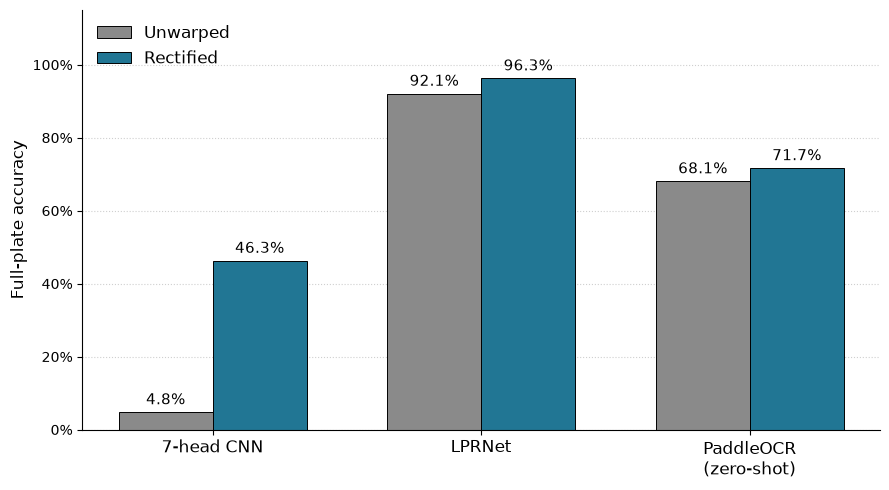

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Dati inseriti a mano
modelli = ['7-head CNN', 'LPRNet', 'PaddleOCR\n(zero-shot)']
unwarped = [4.8, 92.1, 68.1]
rectified = [46.3, 96.3, 71.7]

# 2. Impostazioni di base del grafico
x = np.arange(len(modelli))
width = 0.35  # larghezza delle barre

fig, ax = plt.subplots(figsize=(9, 5))

# 3. Creazione delle barre con colori simili all'immagine originale
barre_unwarped = ax.bar(x - width/2, unwarped, width, label='Unwarped', 
                        color='#8A8A8A', edgecolor='black', linewidth=0.7)
barre_rectified = ax.bar(x + width/2, rectified, width, label='Rectified', 
                         color='#217694', edgecolor='black', linewidth=0.7)

# 4. Personalizzazione degli assi e delle etichette
ax.set_ylabel('Full-plate accuracy', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(modelli, fontsize=12)
ax.set_ylim(0, 115) # Margine superiore per non tagliare i numeri sopra le barre

# Formattazione dell'asse Y in percentuale (da 0 a 100 a scatti di 20)
ax.set_yticks(np.arange(0, 120, 20))
ax.yaxis.set_major_formatter('{x:.0f}%')

# 5. Estetica: griglia e bordi
ax.yaxis.grid(True, linestyle=':', alpha=0.6)
ax.set_axisbelow(True) # Assicura che la griglia stia dietro le barre

# Rimuove i bordi superiore e destro (spines) per un look più pulito
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 6. Etichette con i valori esatti sopra le barre
ax.bar_label(barre_unwarped, padding=3, fmt='%.1f%%', fontsize=11)
ax.bar_label(barre_rectified, padding=3, fmt='%.1f%%', fontsize=11)

# 7. Legenda posizionata in alto a sinistra senza bordo
ax.legend(loc='upper left', frameon=False, fontsize=12)

# Mostra il grafico
plt.tight_layout()
plt.show()

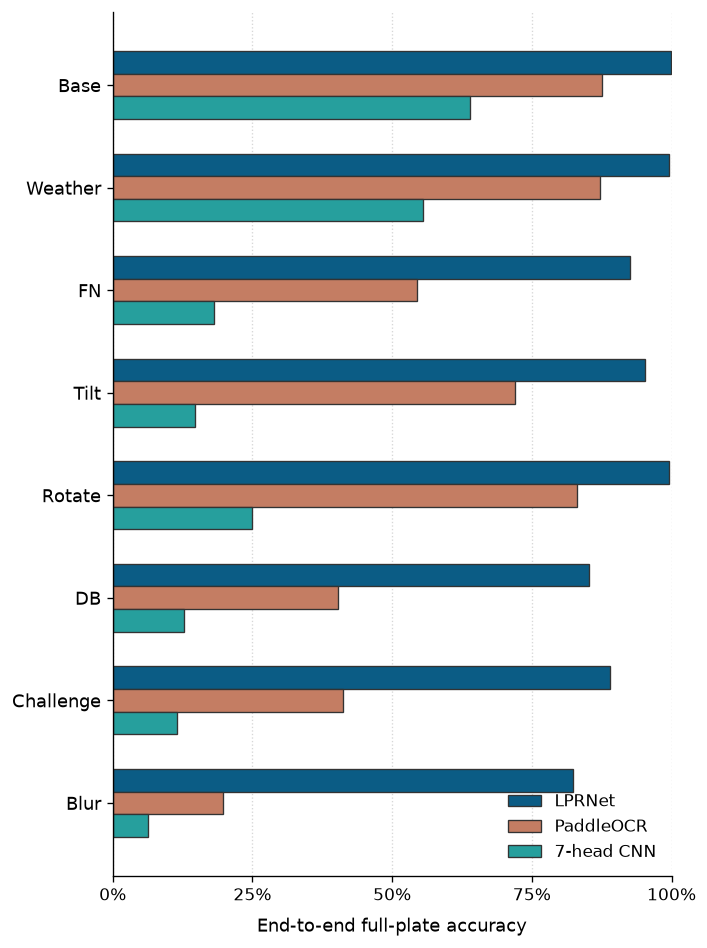

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Dati estratti dalla tabella (ordine top-down del grafico)
subsets = ['Base', 'Weather', 'FN', 'Tilt', 'Rotate', 'DB', 'Challenge', 'Blur']

# Valori in percentuale (moltiplicati per 100 rispetto allo 0.xxx della tabella)
lprnet = [99.92, 99.55, 92.56, 95.18, 99.50, 85.20, 88.94, 82.33]
paddleocr = [87.49, 87.27, 54.37, 72.02, 83.08, 40.31, 41.23, 19.67]
cnn_7head = [64.00, 55.45, 18.12, 14.68, 24.88, 12.76, 11.53, 6.33]

# Setup della figura
fig, ax = plt.subplots(figsize=(6, 8), dpi=120)

# Posizioni sull'asse Y e spessore delle barre
y = np.arange(len(subsets))
height = 0.22 

# Palette colori campionata dall'immagine originale
color_lprnet = '#0b5c85'  # Blu scuro
color_paddle = '#c47d63'  # Terracotta
color_cnn = '#269f9d'     # Ottanio/Teal

# Creazione delle barre con bordo sottile nero scuro (come nell'immagine)
ax.barh(y - height, lprnet, height, label='LPRNet', color=color_lprnet, edgecolor='#333333', linewidth=0.8)
ax.barh(y, paddleocr, height, label='PaddleOCR', color=color_paddle, edgecolor='#333333', linewidth=0.8)
ax.barh(y + height, cnn_7head, height, label='7-head CNN', color=color_cnn, edgecolor='#333333', linewidth=0.8)

# Configurazione asse Y
ax.set_yticks(y)
ax.set_yticklabels(subsets, fontsize=11)
ax.invert_yaxis()  # Inverte l'asse per avere 'Base' in alto e 'Blur' in basso

# Configurazione asse X
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=10)
ax.set_xlabel('End-to-end full-plate accuracy', fontsize=11, labelpad=8)

# Stile della griglia (solo verticale, punteggiata, in secondo piano)
ax.xaxis.grid(True, linestyle=':', color='lightgray', alpha=0.9)
ax.set_axisbelow(True)

# Rimozione degli "spines" (bordi) superiore e destro
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Configurazione Legenda
ax.legend(loc='lower right', frameon=False, fontsize=10)

# Ottimizzazione degli spazi
plt.tight_layout()
plt.show()

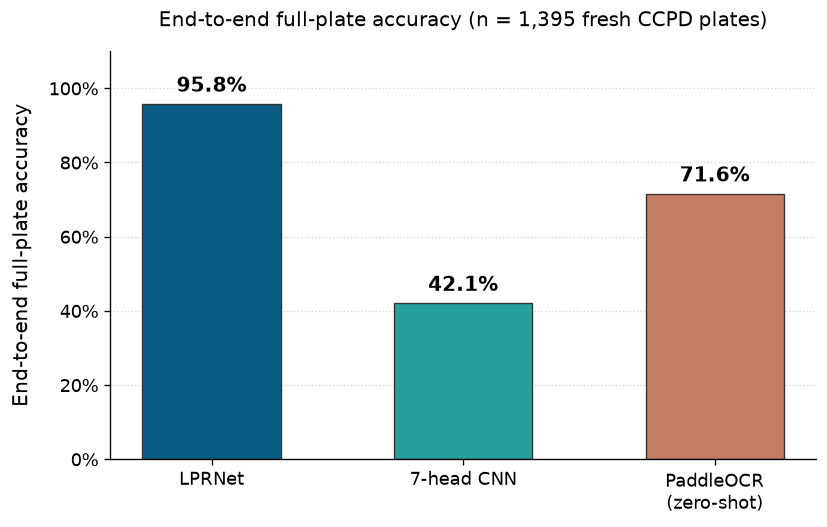

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# INSERISCI I TUOI DATI QUI
# ==========================================
# Valori in percentuale (es. 94.8 per 94.8%)
valore_lprnet = 95.8
valore_cnn = 42.1
valore_paddle = 71.6

# Testo del titolo
titolo_grafico = "End-to-end full-plate accuracy (n = 1,395 fresh CCPD plates)"
# ==========================================

# Preparazione dati
models = ['LPRNet', '7-head CNN', 'PaddleOCR\n(zero-shot)']
accuracies = [valore_lprnet, valore_cnn, valore_paddle]

# Colori campionati dall'immagine
colors = ['#0b5c85', '#269f9d', '#c47d63']

# Setup della figura
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=120)

# Creazione delle barre verticali
bars = ax.bar(models, accuracies, color=colors, edgecolor='#333333', linewidth=0.8, width=0.55)

# Aggiunta dei valori in percentuale sopra ogni barra
for bar in bars:
    yval = bar.get_height()
    # Posiziona il testo al centro della barra, leggermente sopra il limite superiore
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", 
            ha='center', va='bottom', fontweight='bold', fontsize=12)

# Configurazione asse Y
ax.set_ylim(0, 110)  # Limite a 110 per lasciare spazio alle etichette di testo
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'], fontsize=11)
ax.set_ylabel('End-to-end full-plate accuracy', fontsize=12, labelpad=10)

# Configurazione asse X
ax.tick_params(axis='x', labelsize=11)

# Impostazione del titolo
ax.set_title(titolo_grafico, fontsize=12, pad=15)

# Stile della griglia (solo orizzontale, punteggiata, in secondo piano)
ax.yaxis.grid(True, linestyle=':', color='lightgray', alpha=0.9)
ax.set_axisbelow(True)

# Rimozione dei bordi superiore e destro
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ottimizzazione degli spazi
plt.tight_layout()
plt.show()